# Set up và thêm các thư viện cần thiết

In [1]:
import os
import json
import time
import logging
import warnings
import platform
import tracemalloc
import glob
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import cv2

from scipy import stats
import scipy.ndimage as ndimage

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout

from IPython.display import display

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten,
                                      Dense, Dropout, Concatenate,
                                      BatchNormalization)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

# Đã bỏ param_grid vì sẽ tách riêng 2 model
CONFIG={
    'seed': 42, 
    'blocks': (4,4), 
    'cv_folds': 5,
    'outdir': 'results'
}
np.random.seed(CONFIG['seed'])
tf.random.set_seed(CONFIG['seed']) 
os.makedirs(CONFIG['outdir'],exist_ok=True)

# Hiển thị log trực tiếp trên Jupyter
logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s', force=True)

# Các hàm load datasets

In [2]:
def load_ck_plus(dataset_path):
    X, y = [], []
    emotions = ['anger', 'contempt', 'disgust', 'fear', 'happy', 'sadness', 'surprise']
    
    for label, emotion in enumerate(emotions):
        folder_path = os.path.join(dataset_path, emotion)
        if not os.path.exists(folder_path) and emotion == 'happy': 
            folder_path = os.path.join(dataset_path, 'happiness')
            
        if not os.path.exists(folder_path): continue
            
        for filename in os.listdir(folder_path):
            if filename.endswith(".DS_Store"): continue
            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, (48, 48))
                X.append(img / 255.0)
                y.append(label)
    return X, np.array(y)

def load_cfd_detection_nested(cfd_images_path, clutter_path, max_faces=1410):
    X, y = [], []
    
    # 1. THU THẬP TẤT CẢ ẢNH KHUÔN MẶT TỪ CFD
    face_files = []
    sub_datasets = ['CFD', 'CFD-INDIA', 'CFD-MR']
    for sub_ds in sub_datasets:
        ds_path = os.path.join(cfd_images_path, sub_ds)
        if not os.path.exists(ds_path): continue

        for root, dirs, files in os.walk(ds_path):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    face_files.append(os.path.join(root, file))
                    
    # Trộn ngẫu nhiên danh sách ảnh khuôn mặt
    np.random.shuffle(face_files)
    
    # Bắt đầu nạp ảnh vào mảng cho đến khi đạt đủ max_faces (1410)
    face_count = 0
    for img_path in face_files:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (64, 64))
            X.append(img / 255.0)
            y.append(1) # Nhãn 1 cho Face
            face_count += 1
            if face_count >= max_faces: break

    # 2. THU THẬP ẢNH RÁC (CLUTTER)
    clutter_count = 0
    if os.path.exists(clutter_path):
        clutter_files = glob.glob(os.path.join(clutter_path, '**', '*.*'), recursive=True)
        clutter_files = [f for f in clutter_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        # Trộn ngẫu nhiên ảnh phong cảnh
        np.random.shuffle(clutter_files)

        for img_path in clutter_files:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, (64, 64))
                X.append(img / 255.0)
                y.append(0) # Nhãn 0 cho Clutter
                clutter_count += 1
                # Cân bằng đúng số lượng với Face (sẽ dừng ở 1410)
                if clutter_count >= face_count: break 

    return X, np.array(y)

# Các hàm tiện ích và các LBPs

In [3]:
def preprocess(img):
    x = (img * 255).astype(np.uint8) if img.max() <= 1 else img.astype(np.uint8)
    return x

def neigh(p):
    return (p[:-2,:-2], p[:-2,1:-1], p[:-2,2:], p[1:-1,2:], p[2:,2:], p[2:,1:-1], p[2:,:-2], p[1:-1,:-2])

def hist(v, target_bins, range_max):
    h, _ = np.histogram(v.ravel(), bins=target_bins, range=(0, range_max))
    return h / (h.sum() + 1e-9)

def stlbp(im):
    p = np.pad(im, 1, mode='edge'); C = im; P1,P2,P3,P4,P5,P6,P7,P8 = neigh(p)
    code = (P1>=C)+2*(P2>=C)+4*(P3>=C)+8*(P4>=C)+16*(P5>=C)+32*(P6>=C)+64*(P7>=C)+128*(P8>=C)
    return hist(code, target_bins=16, range_max=256)

def sylbp8(im):
    p = np.pad(im, 1, mode='edge'); P1,P2,P3,P4,P5,P6,P7,P8 = neigh(p)
    code = (P1>=P5)+2*(P2>=P6)+4*(P3>=P7)+8*(P4>=P8)+16*(P5>=P1)+32*(P6>=P2)+64*(P7>=P3)+128*(P8>=P4)
    return hist(code, target_bins=16, range_max=256)

def sylbp4(im):
    p = np.pad(im, 1, mode='edge'); P1,P2,P3,P4,P5,P6,P7,P8 = neigh(p)
    code = (P5>=P1)+2*(P6>=P2)+4*(P7>=P3)+8*(P8>=P4)
    return hist(code, target_bins=16, range_max=16)

MAP = {'stlbp': stlbp, 'sylbp8': sylbp8, 'sylbp4': sylbp4}

def check_redundancy(image):
    p = np.pad(image, 1, mode='edge'); P1,P2,P3,P4,P5,P6,P7,P8 = neigh(p)
    d1 = (P1 >= P5).astype(int).ravel()
    d5 = (P5 >= P1).astype(int).ravel()
    corr, _ = stats.pearsonr(d1, d5)
    logging.info(f"Pearson correlation (H(d1), H(d5)): {corr:.4f}")

def features(images, method):
    br, bc = CONFIG['blocks']
    bins = 16 
    
    X = np.zeros((len(images), br * bc * bins), dtype=np.float32)
    for n, img in enumerate(images):
        im = preprocess(img)
        h, w = im.shape
        ys = np.array_split(np.arange(h), br)
        xs = np.array_split(np.arange(w), bc)
        ptr = 0
        for ry in ys:
            for cx in xs:
                block = im[np.ix_(ry, cx)]
                X[n, ptr:ptr+bins] = MAP[method](block)
                ptr += bins
                
    return X

# Thực hiện đánh giá

In [4]:
def evaluate_separated(name, images, y):
    logging.info(f"\n{'='*50}\n--- ĐÁNH GIÁ DATASET: {name} ({len(images)} samples) ---\n{'='*50}")
    
    os.makedirs(CONFIG['outdir'], exist_ok=True)
    
    methods = ['stlbp', 'sylbp8', 'sylbp4']
    
    svm_models = {
        'Linear': SVC(kernel='linear', C=10, probability=True, random_state=CONFIG['seed']),
        'RBF_g100': SVC(kernel='rbf', C=10, gamma=100, probability=True, random_state=CONFIG['seed']),
        'RBF_scale': SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=CONFIG['seed'])
    }
    
    # Đã cập nhật đủ 7 nhãn cảm xúc
    if 'CKPlus48' in name:
        class_names = ['anger', 'contempt', 'disgust', 'fear', 'happiness', 'sadness', 'surprise']
    else:
        class_names = ['clutter', 'face'] 

    table_data = {cls: {} for cls in class_names}
    table_data['total'] = {}
    rows = [] 
    
    for m in methods:
        t = time.time()
        X = features(images, m)
        ext_time = time.time() - t
        
        # CHIA DỮ LIỆU 70% Train, 30% Test
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=CONFIG['seed'])
        
        for svm_name, clf in svm_models.items():
            clf.fit(Xtr, ytr)
            pred = clf.predict(Xte)
            
            total_acc = accuracy_score(yte, pred)
            cm = confusion_matrix(yte, pred)
            
            # Tính toán phần trăm cho từng lớp
            with np.errstate(divide='ignore', invalid='ignore'):
                per_class_acc = np.true_divide(cm.diagonal(), cm.sum(axis=1))
                per_class_acc[np.isnan(per_class_acc)] = 0
            
            if svm_name == 'Linear': col_name = f"{m.upper()} (Linear)"
            elif svm_name == 'RBF_g100': col_name = f"{m.upper()} (RBF y=100)"
            else: col_name = f"{m.upper()} (RBF scale)"
                
            for idx, cls in enumerate(class_names):
                table_data[cls][col_name] = per_class_acc[idx] * 100
            table_data['total'][col_name] = total_acc * 100
            
            rows.append({
                'dataset': name, 'method': m, 'svm_type': svm_name, 
                'acc_mean': total_acc, 'time': ext_time, 'dim': int(X.shape[1])
            })
            
            if m == 'sylbp4' and svm_name == 'RBF_scale':
                plt.figure(figsize=(7,6))
                plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
                plt.title(f'{name} - SyLBP4 (RBF scale)')
                plt.colorbar()
                plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
                plt.yticks(np.arange(len(class_names)), class_names)
                plt.ylabel('True label'); plt.xlabel('Predicted label')
                plt.tight_layout()
                plt.savefig(os.path.join(CONFIG['outdir'], f'cm_{svm_name}_{name}.png'))
                plt.close()

    df = pd.DataFrame.from_dict(table_data, orient='index')
    
    ordered_cols = []
    for model_type in ['(Linear)', '(RBF y=100)', '(RBF scale)']:
        for method in ['STLBP', 'SYLBP8', 'SYLBP4']:
            ordered_cols.append(f"{method} {model_type}")
    
    df = df[ordered_cols].round(2)
    print(f"\nBẢNG KẾT QUẢ ĐỘ CHÍNH XÁC (%) TRÊN TẬP TEST 30% - DATASET: {name}")
    display(df) 
    
    df.to_csv(os.path.join(CONFIG['outdir'], f'Table_{name}.csv'))
    return rows

# Bonus: Weekness

In [5]:
def evaluate_sylbp4_weaknesses(name, images, y):
    logging.info(f"\n{'='*50}\n--- BONUS 1: PHÂN TÍCH ĐIỂM YẾU (WEAKNESS) CỦA SyLBP4 TRÊN {name} ---\n{'='*50}")
    weakness_dir = os.path.join(CONFIG['outdir'], 'weakness')
    os.makedirs(weakness_dir, exist_ok=True)
    idx = np.arange(len(images))
    idx_tr, idx_te, ytr, yte = train_test_split(idx, y, test_size=0.3, stratify=y, random_state=CONFIG['seed'])
    
    train_images = [images[i] for i in idx_tr]
    test_images = [images[i] for i in idx_te]

    logging.info("Đang trích xuất đặc trưng cho tập Train...")
    Xtr_stlbp = features(train_images, 'stlbp')
    Xtr_sylbp4 = features(train_images, 'sylbp4')
    
    clf_st = SVC(kernel='linear', C=10, probability=True, random_state=CONFIG['seed'])
    clf_sy = SVC(kernel='linear', C=10, probability=True, random_state=CONFIG['seed'])
    
    clf_st.fit(Xtr_stlbp, ytr)
    clf_sy.fit(Xtr_sylbp4, ytr)

    # Hàm vẽ biểu đồ đường (Line chart) so sánh StLBP và SyLBP4
    def plot_weakness(labels, acc_st, acc_sy, title, xlabel, filename):
        plt.figure(figsize=(7, 5))
        plt.plot(labels, acc_st, marker='o', linestyle='-', color='#2980b9', linewidth=2, label='StLBP (8-bit)')
        plt.plot(labels, acc_sy, marker='s', linestyle='--', color='#e74c3c', linewidth=2, label='SyLBP4 (4-bit)')
        plt.title(title, fontweight='bold', fontsize=14)
        plt.xlabel(xlabel, fontweight='bold')
        plt.ylabel('Accuracy (%)', fontweight='bold')
        plt.ylim(0, 105)
        plt.legend(loc='lower left')
        plt.grid(linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.savefig(os.path.join(weakness_dir, filename), dpi=300)
        plt.close()

    # =======================================================
    # BÀI TEST 1: KHÁNG NHIỄU (NOISE SENSITIVITY - Salt & Pepper)
    # =======================================================
    noise_levels = [0.0, 0.05, 0.1, 0.2, 0.3] 
    acc_st_noise, acc_sy_noise = [], []
    
    def add_sp_noise(img, p):
        if p == 0: return img
        noisy = np.copy(img)
        mask = np.random.rand(*img.shape)
        noisy[mask < p / 2] = 0.0      # Pepper (Đen)
        noisy[(mask >= p / 2) & (mask < p)] = 1.0 # Salt (Trắng)
        return noisy

    logging.info("Đang chạy Bài test 1: Noise Sensitivity...")
    for p in noise_levels:
        noisy_tests = [add_sp_noise(img, p) for img in test_images]
        Xte_st = features(noisy_tests, 'stlbp')
        Xte_sy = features(noisy_tests, 'sylbp4')
        acc_st_noise.append(accuracy_score(yte, clf_st.predict(Xte_st)) * 100)
        acc_sy_noise.append(accuracy_score(yte, clf_sy.predict(Xte_sy)) * 100)
        
    plot_weakness(noise_levels, acc_st_noise, acc_sy_noise, 
                  f'Noise Sensitivity - {name}', 'Salt & Pepper Probability', 
                  f'1_noise_sensitivity_{name}.png')

    # =======================================================
    # BÀI TEST 2: ĐỘ MỜ (BLUR LIMITATION - Gaussian Blur)
    # =======================================================
    blur_kernels = [1, 3, 5, 7, 9] # Kích thước kernel làm mờ
    acc_st_blur, acc_sy_blur = [], []
    
    logging.info("Đang chạy Bài test 2: Blur Limitation...")
    for k in blur_kernels:
        if k == 1:
            blurred_tests = test_images
        else:
            blurred_tests = [cv2.GaussianBlur(img.astype(np.float32), (k,k), 0) for img in test_images]
        Xte_st = features(blurred_tests, 'stlbp')
        Xte_sy = features(blurred_tests, 'sylbp4')
        acc_st_blur.append(accuracy_score(yte, clf_st.predict(Xte_st)) * 100)
        acc_sy_blur.append(accuracy_score(yte, clf_sy.predict(Xte_sy)) * 100)
        
    plot_weakness(blur_kernels, acc_st_blur, acc_sy_blur, 
                  f'Blur Limitation - {name}', 'Gaussian Kernel Size', 
                  f'2_blur_limitation_{name}.png')

    # =======================================================
    # BÀI TEST 3: GÓC XOAY (ROTATION VARIANCE)
    # =======================================================
    angles = [0, 5, 15, 30, 45] # Đâm nghiêng ảnh
    acc_st_rot, acc_sy_rot = [], []
    
    logging.info("Đang chạy Bài test 3: Rotation Variance...")
    for a in angles:
        if a == 0:
            rot_tests = test_images
        else:
            # Dùng ndimage.rotate để xoay ảnh, mode='nearest' để viền không bị đen quá nhiều
            rot_tests = [ndimage.rotate(img, a, reshape=False, mode='nearest') for img in test_images]
        Xte_st = features(rot_tests, 'stlbp')
        Xte_sy = features(rot_tests, 'sylbp4')
        acc_st_rot.append(accuracy_score(yte, clf_st.predict(Xte_st)) * 100)
        acc_sy_rot.append(accuracy_score(yte, clf_sy.predict(Xte_sy)) * 100)
        
    plot_weakness(angles, acc_st_rot, acc_sy_rot, 
                  f'Rotation Variance - {name}', 'Rotation Angle (Degrees)', 
                  f'3_rotation_variance_{name}.png')

    logging.info(f"Hoàn tất! Biểu đồ điểm yếu đã được lưu vào thư mục: {weakness_dir}")


# Bonus :  SyLBP4 + CNN vs raw CNN 

In [6]:
def get_sylbp4_spatial_map(images):
    """
    raw --> SyLBP4.
    """
    sylbp_images = []
    for img in images:
        # Preprocess
        im = preprocess(img) 
        p = np.pad(im, 1, mode='edge')
        P1,P2,P3,P4,P5,P6,P7,P8 = neigh(p)
        
        code = (P5>=P1)+2*(P6>=P2)+4*(P7>=P3)+8*(P8>=P4)
        
        # ormalized [0, 1] 
        code_normalized = code.astype(np.float32) / 15.0
        
        sylbp_images.append(code_normalized)
        
    return np.array(sylbp_images)

def build_standard_cnn(input_shape, num_classes):
    out_units = num_classes if num_classes > 2 else 1
    out_activation = 'softmax' if num_classes > 2 else 'sigmoid'
    
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2,2)),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(out_units, activation=out_activation)
    ])
    
    loss_fn = 'sparse_categorical_crossentropy' if num_classes > 2 else 'binary_crossentropy'
    model.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])
    return model

def run_cnn_comparison(name, images, y):
    logging.info(f"\n{'='*50}\n--- SO SÁNH: RAW CNN vs SyLBP4-CNN TRÊN {name} ---\n{'='*50}")
    
    num_classes = len(np.unique(y))
    epochs = 20
    batch_size = 32
    h, w = images[0].shape
    input_shape = (h, w, 1)

    # prepare data
    X_raw = np.array(images).reshape(-1, h, w, 1)
    
    t_extract_start = time.time()
    X_sylbp4 = get_sylbp4_spatial_map(images).reshape(-1, h, w, 1)
    t_extract = time.time() - t_extract_start
    logging.info(f"time for feature extraction: {t_extract:.2f}s")

    # split Train/Test )
    Xr_train, Xr_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.3, stratify=y, random_state=CONFIG['seed'])
    Xs_train, Xs_test, _, _ = train_test_split(X_sylbp4, y, test_size=0.3, stratify=y, random_state=CONFIG['seed'])

    results = {}

    # train : Raw CNN
    model_raw = build_standard_cnn(input_shape, num_classes)
    
    t0 = time.time()
    hist_raw = model_raw.fit(Xr_train, y_train, validation_data=(Xr_test, y_test), 
                             epochs=epochs, batch_size=batch_size, verbose=0)
    t_train_raw = time.time() - t0
    
    t0 = time.time()
    loss_raw, acc_raw = model_raw.evaluate(Xr_test, y_test, verbose=0)
    t_infer_raw = time.time() - t0

    # train : SyLBP4-CNN
    model_sy = build_standard_cnn(input_shape, num_classes)
    
    t0 = time.time()
    hist_sy = model_sy.fit(Xs_train, y_train, validation_data=(Xs_test, y_test), 
                           epochs=epochs, batch_size=batch_size, verbose=0)
    t_train_sy = time.time() - t0
    
    t0 = time.time()
    loss_sy, acc_sy = model_sy.evaluate(Xs_test, y_test, verbose=0)
    t_infer_sy = time.time() - t0

    results['Raw_CNN'] = {
        'acc': acc_raw * 100, 't_train': t_train_raw, 't_infer': t_infer_raw, 'history': hist_raw.history
    }
    results['SyLBP4_CNN'] = {
        'acc': acc_sy * 100, 't_train': t_train_sy, 't_infer': t_infer_sy, 'history': hist_sy.history
    }
    
    logging.info(f"[Raw CNN]      Acc: {acc_raw*100:.2f}% | Train: {t_train_raw:.2f}s | Infer: {t_infer_raw:.2f}s")
    logging.info(f"[SyLBP4 + CNN] Acc: {acc_sy*100:.2f}% | Train: {t_train_sy:.2f}s | Infer: {t_infer_sy:.2f}s")
    
    return results

# Hàm vẽ biểu đồ

In [7]:
def dashboard_bar_chart(all_rows):
    datasets = sorted(set(r['dataset'] for r in all_rows))
    methods = ['stlbp', 'sylbp8', 'sylbp4']
    
    for ds in datasets:
        lin_data = [r for r in all_rows if r['dataset']==ds and r['svm_type']=='Linear']
        rbf_g100_data = [r for r in all_rows if r['dataset']==ds and r['svm_type']=='RBF_g100']
        rbf_scale_data = [r for r in all_rows if r['dataset']==ds and r['svm_type']=='RBF_scale']
        
        def get_acc(data_list):
            acc_dict = {r['method']: r['acc_mean']*100 for r in data_list}
            return [acc_dict.get(m, 0) for m in methods]
            
        lin_acc = get_acc(lin_data)
        rbf_g100_acc = get_acc(rbf_g100_data)
        rbf_scale_acc = get_acc(rbf_scale_data)
        
        x = np.arange(len(methods))
        width = 0.25 
        
        fig, ax = plt.subplots(figsize=(10, 6))

        rects1 = ax.bar(x - width, lin_acc, width, label='Linear SVM', color='#2c3e50') 
        rects2 = ax.bar(x, rbf_g100_acc, width, label='RBF SVM ($\gamma=100$)', color='#e74c3c') 
        rects3 = ax.bar(x + width, rbf_scale_acc, width, label='RBF SVM ($\gamma=scale$)', color='#27ae60') 
        
        ax.set_ylabel('Total Accuracy (%)', fontsize=12, fontweight='bold')
        ax.set_title(f'Comparison of LBP Methods & SVM Kernels on {ds}', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([m.upper() for m in methods], fontsize=12, fontweight='bold')
        ax.set_ylim(0, 115) # Tăng trần để lấy chỗ ghi số không bị cắt mất
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=11, framealpha=0.9)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        def autolabel(rects):
            for rect in rects:
                height = rect.get_height()
                if height > 0:
                    ax.annotate(f'{height:.2f}%',
                                xy=(rect.get_x() + rect.get_width() / 2, height),
                                xytext=(0, 3), 
                                textcoords="offset points",
                                ha='center', va='bottom', fontsize=10, fontweight='bold')
                    
        autolabel(rects1)
        autolabel(rects2)
        autolabel(rects3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(CONFIG['outdir'], f'acc_bar_chart_{ds}.png'), dpi=300)
        plt.close()

def dashboard_heatmap(all_rows):
    datasets = sorted(set(r['dataset'] for r in all_rows))
    methods = ['stlbp', 'sylbp8', 'sylbp4']
    svm_types = ['Linear', 'RBF_g100', 'RBF_scale']
    
    for ds in datasets:
        # Tạo ma trận dữ liệu 3x3
        data_matrix = np.zeros((len(methods), len(svm_types)))
        for i, m in enumerate(methods):
            for j, s in enumerate(svm_types):
                val = next((r['acc_mean']*100 for r in all_rows if r['dataset']==ds and r['method']==m and r['svm_type']==s), 0)
                data_matrix[i, j] = val
                
        fig, ax = plt.subplots(figsize=(8, 6))
        cax = ax.matshow(data_matrix, cmap='YlGnBu', vmin=0, vmax=100)
        fig.colorbar(cax, fraction=0.046, pad=0.04, label='Accuracy (%)')
        
        ax.set_xticks(np.arange(len(svm_types)))
        ax.set_yticks(np.arange(len(methods)))
        ax.set_xticklabels(['Linear SVM', 'RBF ($\gamma=100$)', 'RBF ($\gamma=scale$)'], fontsize=11, fontweight='bold')
        ax.set_yticklabels([m.upper() for m in methods], fontsize=11, fontweight='bold')
        ax.xaxis.set_ticks_position('bottom')
        
        # In số liệu trực tiếp lên từng ô vuông
        for i in range(len(methods)):
            for j in range(len(svm_types)):
                val = data_matrix[i, j]
                color = "white" if val > 55 else "black"
                ax.text(j, i, f"{val:.2f}%", ha="center", va="center", color=color, fontweight='bold', fontsize=12)
        
        plt.title(f'Accuracy Heatmap - {ds}', pad=20, fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(CONFIG['outdir'], f'acc_heatmap_{ds}.png'), dpi=300)
        plt.close()

def dashboard_extraction_time(all_rows):
    datasets = sorted(set(r['dataset'] for r in all_rows))
    methods = ['stlbp', 'sylbp8', 'sylbp4']
    
    for ds in datasets:
        times = []
        for m in methods:
            # Lấy thời gian trích xuất của từng phương pháp
            t = next(r['time'] for r in all_rows if r['dataset']==ds and r['method']==m)
            times.append(t)
            
        plt.figure(figsize=(8, 6))

        bars = plt.bar([m.upper() for m in methods], times, color=['#34495e', '#7f8c8d', '#1abc9c'], width=0.5)
        
        plt.title(f'Feature Extraction Time Comparison - {ds}', fontsize=14, fontweight='bold', pad=15)
        plt.ylabel('Extraction Time (Seconds)', fontsize=12, fontweight='bold')
        plt.xticks(fontsize=12, fontweight='bold')
        
        # Tăng trần đồ thị lên 15% để có chỗ ghi số liệu không bị cắt
        plt.ylim(0, max(times) * 1.15)
        
        # In số giây (kết quả) trực tiếp lên đỉnh mỗi cột
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}s', 
                     ha='center', va='bottom', fontsize=11, fontweight='bold')
            
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.savefig(os.path.join(CONFIG['outdir'], f'time_lbp_extraction_{ds}.png'), dpi=300)
        plt.close()


def plot_cnn_comparison(name, results):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Deep Learning Comparison on {name}: Raw CNN vs SyLBP4-CNN', fontsize=16, fontweight='bold')

    models = ['Raw CNN', 'SyLBP4 + CNN']
    colors = ['#3498db', '#e74c3c']
    
    accs = [results['Raw_CNN']['acc'], results['SyLBP4_CNN']['acc']]
    t_trains = [results['Raw_CNN']['t_train'], results['SyLBP4_CNN']['t_train']]
    t_infers = [results['Raw_CNN']['t_infer'], results['SyLBP4_CNN']['t_infer']]
    
    hist_raw = results['Raw_CNN']['history']
    hist_sy = results['SyLBP4_CNN']['history']
    epochs_range = range(1, len(hist_raw['accuracy']) + 1)

    # Accuracy
    ax = axes[0, 0]
    bars = ax.bar(models, accs, color=colors, width=0.5)
    ax.set_title('Test Accuracy (%)', fontweight='bold')
    ax.set_ylim(0, 110)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                f'{bar.get_height():.2f}%', ha='center', fontweight='bold')

    #  (Learning Behavior) - Validation Accuracy
    ax = axes[0, 1]
    ax.plot(epochs_range, hist_raw['val_accuracy'], marker='o', label='Raw CNN', color=colors[0])
    ax.plot(epochs_range, hist_sy['val_accuracy'], marker='s', label='SyLBP4 + CNN', color=colors[1])
    ax.set_title('Learning Convergence (Validation Accuracy)', fontweight='bold')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(linestyle='--', alpha=0.6)

    # (Training Time)
    ax = axes[1, 0]
    bars = ax.bar(models, t_trains, color=colors, width=0.5)
    ax.set_title('Training Time (Seconds)', fontweight='bold')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02, 
                f'{bar.get_height():.2f}s', ha='center', fontweight='bold')

    # (Inference Time)
    ax = axes[1, 1]
    bars = ax.bar(models, t_infers, color=colors, width=0.5)
    ax.set_title('Inference Time (Seconds) for Test Set', fontweight='bold')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02, 
                f'{bar.get_height():.4f}s', ha='center', fontweight='bold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(CONFIG['outdir'], f'cnn_comparison_{name}.png'), dpi=300)
    plt.show()

# Main

INFO | Pearson correlation (H(d1), H(d5)): -0.9582
INFO | 
--- ĐÁNH GIÁ DATASET: CKPlus48_Emotion (981 samples) ---



BẢNG KẾT QUẢ ĐỘ CHÍNH XÁC (%) TRÊN TẬP TEST 30% - DATASET: CKPlus48_Emotion


,STLBP (Linear),SYLBP8 (Linear),SYLBP4 (Linear),STLBP (RBF y=100),SYLBP8 (RBF y=100),SYLBP4 (RBF y=100),STLBP (RBF scale),SYLBP8 (RBF scale),SYLBP4 (RBF scale)
anger,80.49,82.93,82.93,0.00,0.00,0.00,87.80,90.24,90.24
contempt,87.50,87.50,87.50,0.00,0.00,0.00,93.75,93.75,93.75
disgust,96.23,98.11,98.11,0.00,0.00,0.00,98.11,100.00,100.00
fear,86.96,86.96,86.96,0.00,0.00,0.00,86.96,86.96,86.96
happiness,100.00,96.77,96.77,4.84,6.45,6.45,100.00,100.00,100.00
sadness,100.00,92.00,92.00,0.00,0.00,0.00,100.00,96.00,96.00
surprise,98.67,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
total,94.58,94.24,94.24,26.44,26.78,26.78,96.61,96.95,96.95


INFO | 
--- SO SÁNH: RAW CNN vs SyLBP4-CNN TRÊN CKPlus48_Emotion ---
INFO | time for feature extraction: 0.12s
INFO | [Raw CNN]      Acc: 96.27% | Train: 13.48s | Infer: 0.15s
INFO | [SyLBP4 + CNN] Acc: 96.27% | Train: 13.62s | Infer: 0.17s


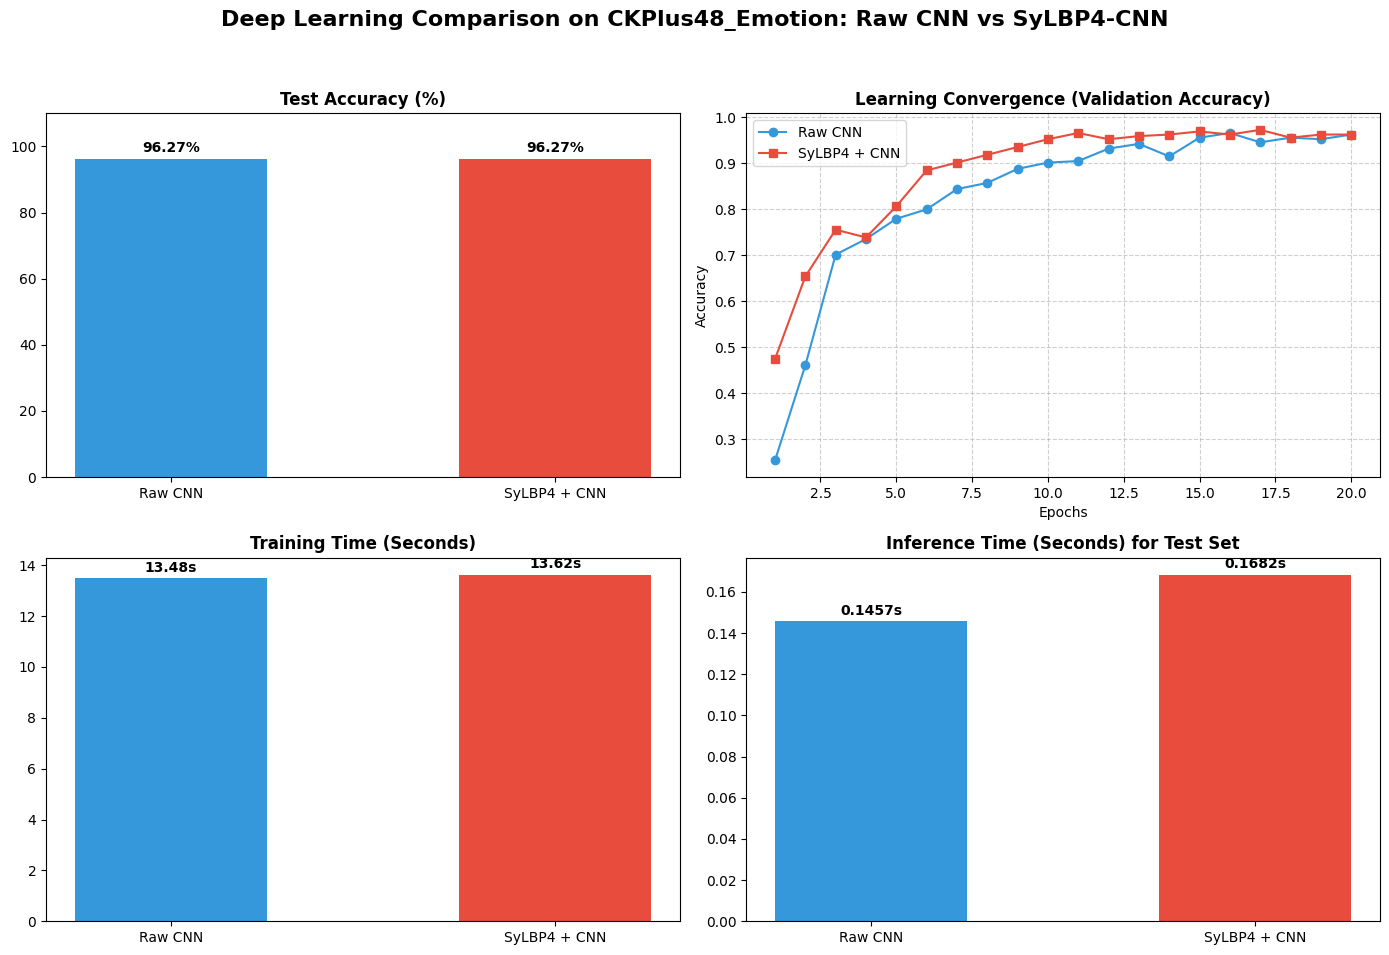

INFO | 
--- BONUS 1: PHÂN TÍCH ĐIỂM YẾU (WEAKNESS) CỦA SyLBP4 TRÊN CKPlus_Emotion ---
INFO | Đang trích xuất đặc trưng cho tập Train...
INFO | Đang chạy Bài test 1: Noise Sensitivity...
INFO | Đang chạy Bài test 2: Blur Limitation...
INFO | Đang chạy Bài test 3: Rotation Variance...
INFO | Hoàn tất! Biểu đồ điểm yếu đã được lưu vào thư mục: results\weakness
INFO | 
--- ĐÁNH GIÁ DATASET: CFD_Detection (2820 samples) ---



BẢNG KẾT QUẢ ĐỘ CHÍNH XÁC (%) TRÊN TẬP TEST 30% - DATASET: CFD_Detection


,STLBP (Linear),SYLBP8 (Linear),SYLBP4 (Linear),STLBP (RBF y=100),SYLBP8 (RBF y=100),SYLBP4 (RBF y=100),STLBP (RBF scale),SYLBP8 (RBF scale),SYLBP4 (RBF scale)
clutter,100.00,100.0,100.0,100.00,100.00,100.00,100.0,100.0,100.0
face,99.76,100.0,100.0,53.66,45.63,45.63,100.0,100.0,100.0
total,99.88,100.0,100.0,76.83,72.81,72.81,100.0,100.0,100.0


INFO | 
--- SO SÁNH: RAW CNN vs SyLBP4-CNN TRÊN CFD_Detection ---
INFO | time for feature extraction: 0.41s
INFO | [Raw CNN]      Acc: 99.88% | Train: 56.07s | Infer: 0.37s
INFO | [SyLBP4 + CNN] Acc: 100.00% | Train: 54.88s | Infer: 0.37s


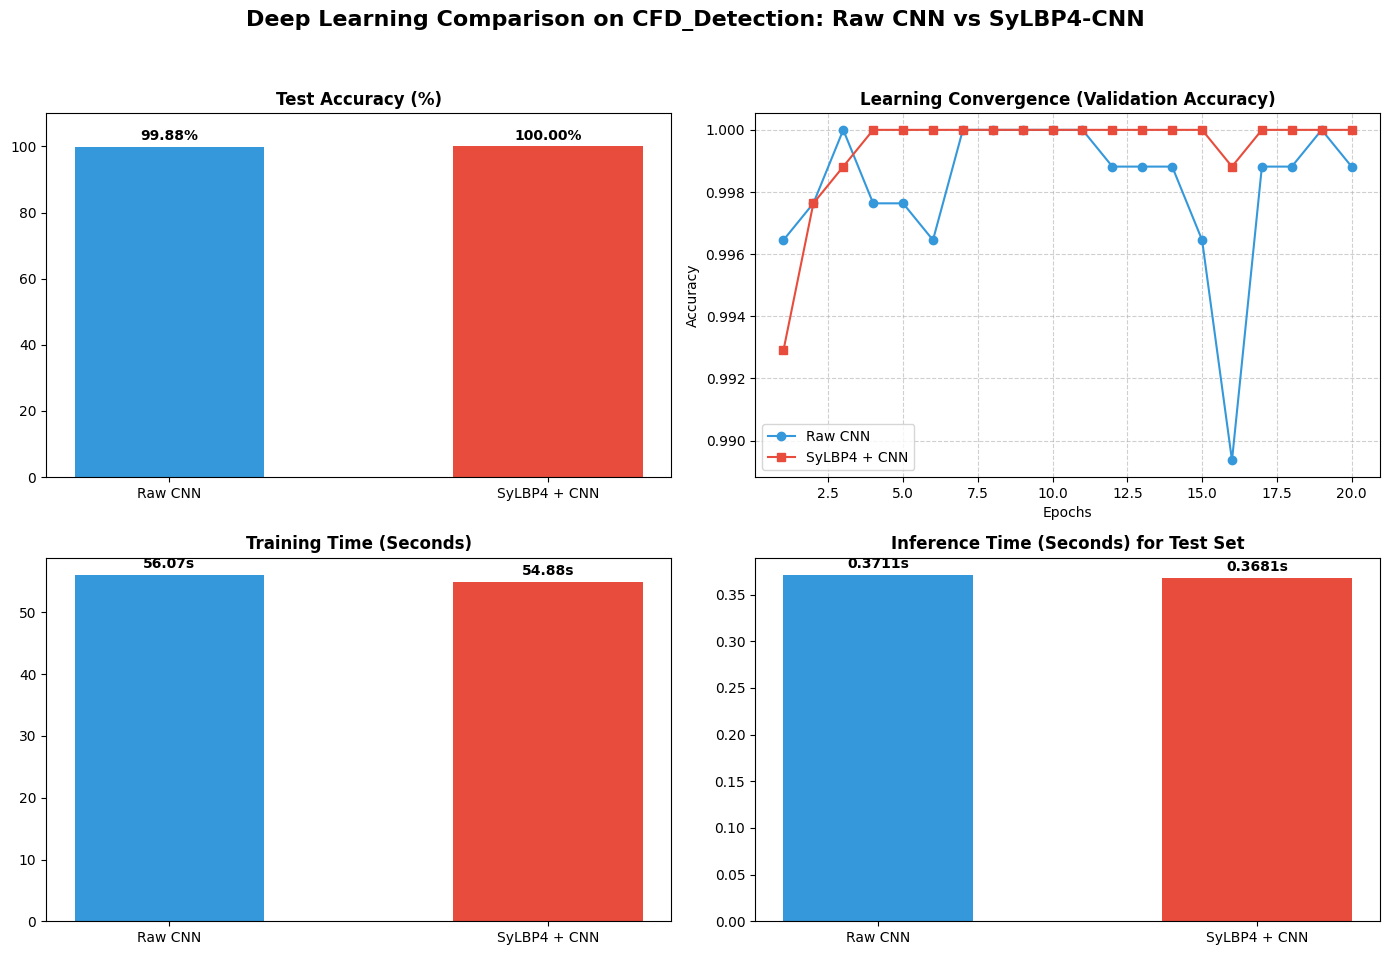

INFO | 
--- BONUS 1: PHÂN TÍCH ĐIỂM YẾU (WEAKNESS) CỦA SyLBP4 TRÊN CFD ---
INFO | Đang trích xuất đặc trưng cho tập Train...
INFO | Đang chạy Bài test 1: Noise Sensitivity...
INFO | Đang chạy Bài test 2: Blur Limitation...
INFO | Đang chạy Bài test 3: Rotation Variance...
INFO | Hoàn tất! Biểu đồ điểm yếu đã được lưu vào thư mục: results\weakness
INFO | HOÀN THÀNH TẤT CẢ THỰC NGHIỆM!
INFO | Vui lòng kiểm tra thư mục 'results' để lấy biểu đồ và bảng kết quả.


In [8]:
def main():
    all_rows = []
    redundancy_checked = False
    
    base_dir = "./datasets"
    ck_path = os.path.join(base_dir, "CK_Plus")
    cfd_path = os.path.join(base_dir, "CFD")
    clutter_path = os.path.join(base_dir, "Clutter_Images")

    # 1. ĐÁNH GIÁ NHẬN DIỆN CẢM XÚC (Tập dữ liệu CK+)
    if os.path.exists(ck_path):
        X_emo, y_emo = load_ck_plus(ck_path)
        if len(X_emo) > 0:
            # Kiểm tra tính dư thừa (Redundancy Check) cho lần đầu tiên
            if not redundancy_checked:
                check_redundancy(X_emo[0])
                redundancy_checked = True
            
            # --- Chạy đánh giá 3 mô hình SVM (Giống Paper) ---
            all_rows += evaluate_separated('CKPlus48_Emotion', X_emo, y_emo)
            
            # Comparision Raw CNN vs SyLBP4-CNN on CKPlus48_Emotion
            results_cnn_emo = run_cnn_comparison('CKPlus48_Emotion', X_emo, y_emo)
            plot_cnn_comparison('CKPlus48_Emotion', results_cnn_emo)

            # --- Phân tích điểm yếu (Weakness) của SyLBP4 ---
            evaluate_sylbp4_weaknesses('CKPlus_Emotion', X_emo, y_emo)

    # 2. ĐÁNH GIÁ PHÁT HIỆN KHUÔN MẶT (Tập dữ liệu CFD vs Clutter)
    if os.path.exists(cfd_path) and os.path.exists(clutter_path):
        # Tải đủ 1410 ảnh Face và 1410 ảnh Clutter như paper (Tổng 2820)
        X_det, y_det = load_cfd_detection_nested(cfd_path, clutter_path, max_faces=1410)
        
        if len(np.unique(y_det)) == 2:
            # --- Chạy đánh giá 3 mô hình SVM (Giống Paper) ---
            all_rows += evaluate_separated('CFD_Detection', X_det, y_det)
            
            # comparision Raw CNN vs SyLBP4-CNN on CFD_Detection 
            results_cnn_det = run_cnn_comparison('CFD_Detection', X_det, y_det)
            plot_cnn_comparison('CFD_Detection', results_cnn_det)

            # --- Phân tích điểm yếu (Weakness) của SyLBP4 ---
            evaluate_sylbp4_weaknesses('CFD', X_det, y_det)
            
            
    # 3. TRỰC QUAN HÓA TOÀN BỘ KẾT QUẢ
    if len(all_rows) > 0:
        dashboard_bar_chart(all_rows)
        dashboard_heatmap(all_rows)
        dashboard_extraction_time(all_rows)
        # Lưu toàn bộ số liệu ra file JSON
        with open(os.path.join(CONFIG['outdir'],'results_separated.json'),'w') as f:
            json.dump({'results': all_rows}, f, indent=2)
            
        logging.info("HOÀN THÀNH TẤT CẢ THỰC NGHIỆM!")
        logging.info("Vui lòng kiểm tra thư mục 'results' để lấy biểu đồ và bảng kết quả.")
    else:
        logging.error("LỖI: Không tìm thấy dữ liệu để xử lý. Hãy kiểm tra lại đường dẫn dataset!")

# Chạy thực thi
main()